In [28]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
import pandas as pd
import os
import json
import re
from utils import load_json
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from matplotlib import pyplot as plt
import seaborn as sns

In [30]:
import os
from utils import *

In [44]:
def importance_to_binary_label(importance):
    importance = int(importance)
    if importance == 1:
        return 1
    else:
        return 0

def classification_to_binary_label(category):
    if 'not' in category:
        print('0 == ', category)
        return 0
    elif 'undecided' in category:
        return -1
    else:
        #print('1 == ', category)
        return 1

def get_df(output_dir = './results_openai/'):
    results = os.listdir(output_dir)

    data = []
    for result in results:
        #print(result)
        result_data = load_json(os.path.join(output_dir, result))
        item_id = result.split("_")[-1].split(".")[0]
        if int(result_data["importance"]) != 1:
            print(result_data["importance"], result_data["cot_facts"]['classification'])
        #if 'undecided' in result_data['round_2']['majority_vote']:
        #    continue

        classification_1 = classification_to_binary_label(result_data['round_1']['majority_vote'])
        classification_2 = classification_to_binary_label(result_data['round_2']['majority_vote'])
        classification_3 = classification_to_binary_label(result_data['round_3']['majority_vote'])
        classification_4 = classification_to_binary_label(result_data['round_4']['majority_vote']) 
        
        importance = int(result_data["importance"])
        ground_truth = importance_to_binary_label(importance)

        data.append(
            {
                "item_id": item_id,
                'classification_1_1': 1 if 'Agent_1' in result_data['round_1']['key_case'] else 0,
                'classification_1_2': 1 if 'Agent_2' in result_data['round_1']['key_case'] else 0,
                'classification_1': classification_1,
                'classification_2': classification_2,
                'classification_3': classification_3,
                'classification_4': classification_4,
                "ground_truth": ground_truth,
                "importance": importance
            }
        )

    df = pd.DataFrame(data)
    return df

def get_metrics_binary(df, column):
    # Key Case vs. All
    # Ground truth: 1 for key case, 0 for not key case
    y_true = df['ground_truth']
    # Model predictions: 1 for key case, 0 for not key case
    y_pred = df[column]

    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="binary")
    recall = recall_score(y_true, y_pred, average="binary")
    f1 = f1_score(y_true, y_pred, average="binary")

    # Classification report for additional insights
    rreport = classification_report(y_true, y_pred, target_names=["Not Key Case", "Key Case"], output_dict=True)
    report = classification_report(y_true, y_pred, target_names=["Not Key Case", "Key Case"])

    # Extracting micro and macro F1 scores
    micro_f1 = rreport["accuracy"]  # Micro F1 is equivalent to accuracy in binary classification
    macro_f1 = rreport["macro avg"]["f1-score"]

    # Presenting results
    metrics = {

        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Micro F1": micro_f1,
        "Macro F1": macro_f1,
    }
    return metrics, report

def get_confusion_matrix(df, column):
    cm = confusion_matrix(df['ground_truth'], df[column], normalize="true")
    return cm

def plot_confusion_matrix(df, column):
    cm = get_confusion_matrix(df, column)
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()



0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not key case
0 ==  not ke

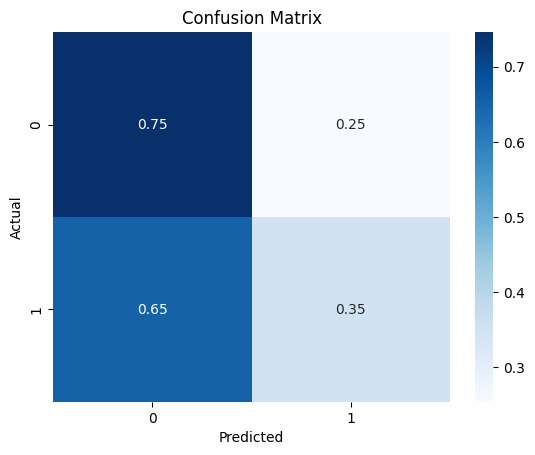

{'Accuracy': 0.5730994152046783,
 'Precision': 0.5148514851485149,
 'Recall': 0.348993288590604,
 'F1 Score': 0.416,
 'Micro F1': 0.5730994152046783,
 'Macro F1': 0.5397972350230414}

In [45]:
df = get_df('./results_fight_openai_a3_r4/')

plot_confusion_matrix(df, "classification_1_1")
metrics, report = get_metrics_binary(df, "classification_1_1")

metrics

In [33]:
print(report)

              precision    recall  f1-score   support

Not Key Case       0.60      0.74      0.66       192
    Key Case       0.51      0.35      0.42       149

    accuracy                           0.57       341
   macro avg       0.56      0.55      0.54       341
weighted avg       0.56      0.57      0.55       341



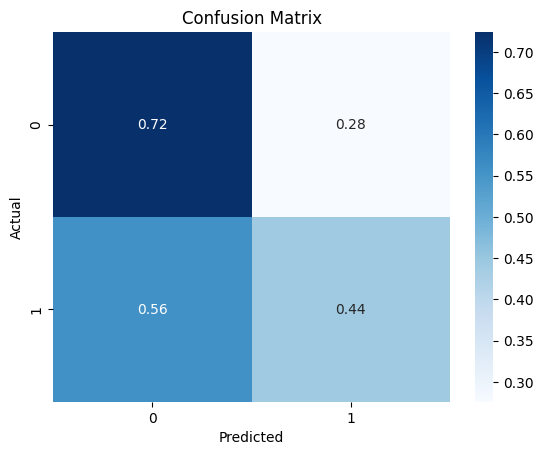

{'Accuracy': 0.6011730205278593,
 'Precision': 0.5546218487394958,
 'Recall': 0.4429530201342282,
 'F1 Score': 0.4925373134328358,
 'Micro F1': 0.6011730205278593,
 'Macro F1': 0.5820174489869493}

In [34]:
df = get_df('./results_fight_openai_a3_r4/')
plot_confusion_matrix(df, "classification_1_2")
metrics, report = get_metrics_binary(df, "classification_1_2")

metrics

there were 1 undecided cases


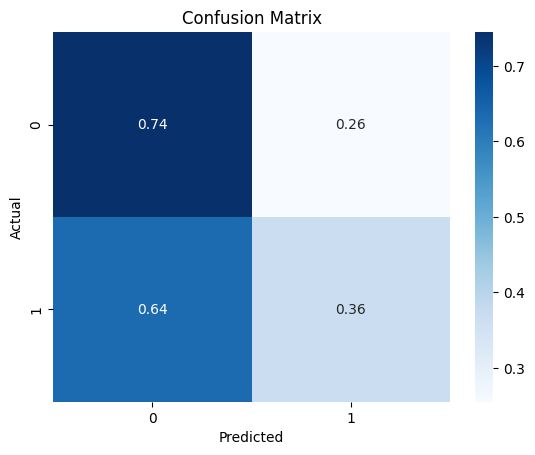

{'Accuracy': 0.5794117647058824,
 'Precision': 0.5242718446601942,
 'Recall': 0.36486486486486486,
 'F1 Score': 0.4302788844621514,
 'Micro F1': 0.5794117647058824,
 'Macro F1': 0.548472775564409}

In [35]:
df = get_df('./results_fight_openai_a3_r4/')
print(f'there were {df[df["classification_1"] == -1].shape[0]} undecided cases')
df = df[df['classification_1'] != -1]
plot_confusion_matrix(df, "classification_1")
metrics, report = get_metrics_binary(df, "classification_1")

metrics

In [36]:
print(report)

              precision    recall  f1-score   support

Not Key Case       0.60      0.74      0.67       192
    Key Case       0.52      0.36      0.43       148

    accuracy                           0.58       340
   macro avg       0.56      0.55      0.55       340
weighted avg       0.57      0.58      0.56       340



there were 1 undecided cases


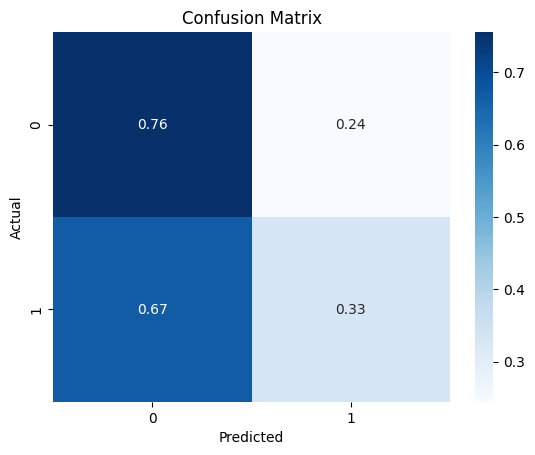

{'Accuracy': 0.5705882352941176,
 'Precision': 0.5104166666666666,
 'Recall': 0.3310810810810811,
 'F1 Score': 0.4016393442622951,
 'Micro F1': 0.5705882352941176,
 'Macro F1': 0.5333884794705971}

In [37]:
df = get_df('./results_fight_openai_a3_r4/')
print(f'there were {df[df["classification_2"] == -1].shape[0]} undecided cases')
df = df[df['classification_2'] != -1]
plot_confusion_matrix(df, "classification_2")
metrics, report = get_metrics_binary(df, "classification_2")

metrics

In [38]:
print(report)

              precision    recall  f1-score   support

Not Key Case       0.59      0.76      0.67       192
    Key Case       0.51      0.33      0.40       148

    accuracy                           0.57       340
   macro avg       0.55      0.54      0.53       340
weighted avg       0.56      0.57      0.55       340



there were 1 undecided cases


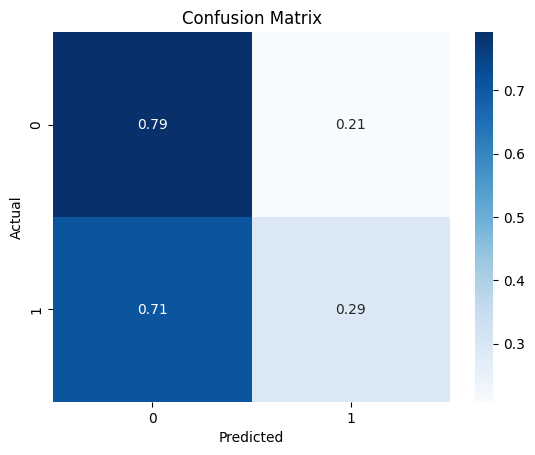

{'Accuracy': 0.5735294117647058,
 'Precision': 0.5180722891566265,
 'Recall': 0.2905405405405405,
 'F1 Score': 0.3722943722943723,
 'Micro F1': 0.5735294117647058,
 'Macro F1': 0.5246772529623309}

In [39]:
df = get_df('./results_fight_openai_a3_r4/')
print(f'there were {df[df["classification_3"] == -1].shape[0]} undecided cases')
df = df[df['classification_3'] != -1]
plot_confusion_matrix(df, "classification_3")
metrics, report = get_metrics_binary(df, "classification_3")

metrics

there were 1 undecided cases


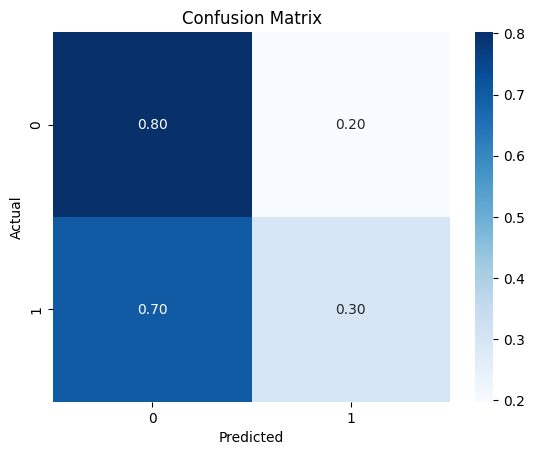

{'Accuracy': 0.5823529411764706,
 'Precision': 0.5365853658536586,
 'Recall': 0.2972972972972973,
 'F1 Score': 0.3826086956521739,
 'Micro F1': 0.5823529411764706,
 'Macro F1': 0.5335265700483092}

In [40]:
df = get_df('./results_fight_openai_a3_r4/')
print(f'there were {df[df["classification_4"] == -1].shape[0]} undecided cases')
df = df[df['classification_3'] != -1]
plot_confusion_matrix(df, "classification_4")
metrics, report = get_metrics_binary(df, "classification_4")

metrics

In [41]:
df

,item_id,classification_1_1,classification_1_2,classification_1,classification_2,classification_3,classification_4,ground_truth,importance
0,001-197098,0,0,0,0,0,0,1,1
1,001-161898,0,0,0,0,0,0,1,1
2,001-215475,0,0,0,0,0,0,0,3
3,001-211123,0,0,0,0,0,0,0,3
4,001-169214,0,0,0,0,0,0,0,3
...,...,...,...,...,...,...,...,...,...
336,001-205536,1,1,1,0,0,0,1,1
337,001-172327,0,0,0,0,0,0,1,1
338,001-168703,0,1,0,0,0,0,0,3
339,001-207360,0,1,1,1,0,1,1,1
